# 03 — Diagnostics: residuals, interval coverage, and the final verdict

**ARICast — forecasting acute respiratory illness (ARI) ED visit load.**

A point forecast with a good MAPE is not the whole story. Before recommending a model for
operational use we check two things any reviewer will ask about:

1. **Residuals** — are the model's out-of-sample errors well-behaved (unbiased, structureless),
   or is there signal the model failed to capture?
2. **Prediction-interval coverage** — the models advertise a 90% interval. Does ~90% of reality
   actually fall inside it, or are the intervals over-confident?

Both are computed on the project's canonical rolling-CV windows for **ARIMA+Fourier** and the
**two-regime Prophet**, across all four horizons. The heavy computation ran locally via
`src/phase3_diagnostics.py`; this notebook reads the cached results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

P = Path("../data/processed")
FIGS = Path("../reports/figures"); FIGS.mkdir(parents=True, exist_ok=True)
cov = pd.read_csv(P / "phase3_coverage.csv")
lb = pd.read_csv(P / "phase3_ljungbox.csv")
ra = pd.read_csv(P / "phase3_residuals_arima.csv")
rp = pd.read_csv(P / "phase3_residuals_prophet.csv")
print("coverage rows:", len(cov), "| residual points:", len(ra), "(arima)", len(rp), "(prophet)")

coverage rows: 16 | residual points: 3870 (arima) 3870 (prophet)


## 1. Prediction-interval coverage

A nominal 90% interval should contain ~90% of actual values. Below that, the model is
**over-confident** (intervals too narrow) — a real risk for staffing decisions, where an
under-stated uncertainty band leads to under-resourcing.

In [2]:
piv = cov.pivot_table(index=["series", "horizon"], columns="model",
                     values="empirical_coverage")
print("Empirical coverage of the nominal 90% interval:")
print(piv.to_string())

Empirical coverage of the nominal 90% interval:
model                  arima  prophet
series        horizon                
California    7        1.000    0.714
              14       0.967    0.643
              30       0.900    0.831
              90       0.841    0.781
United States 7        0.933    0.838
              14       0.933    0.790
              30       0.938    0.900
              90       0.945    0.863


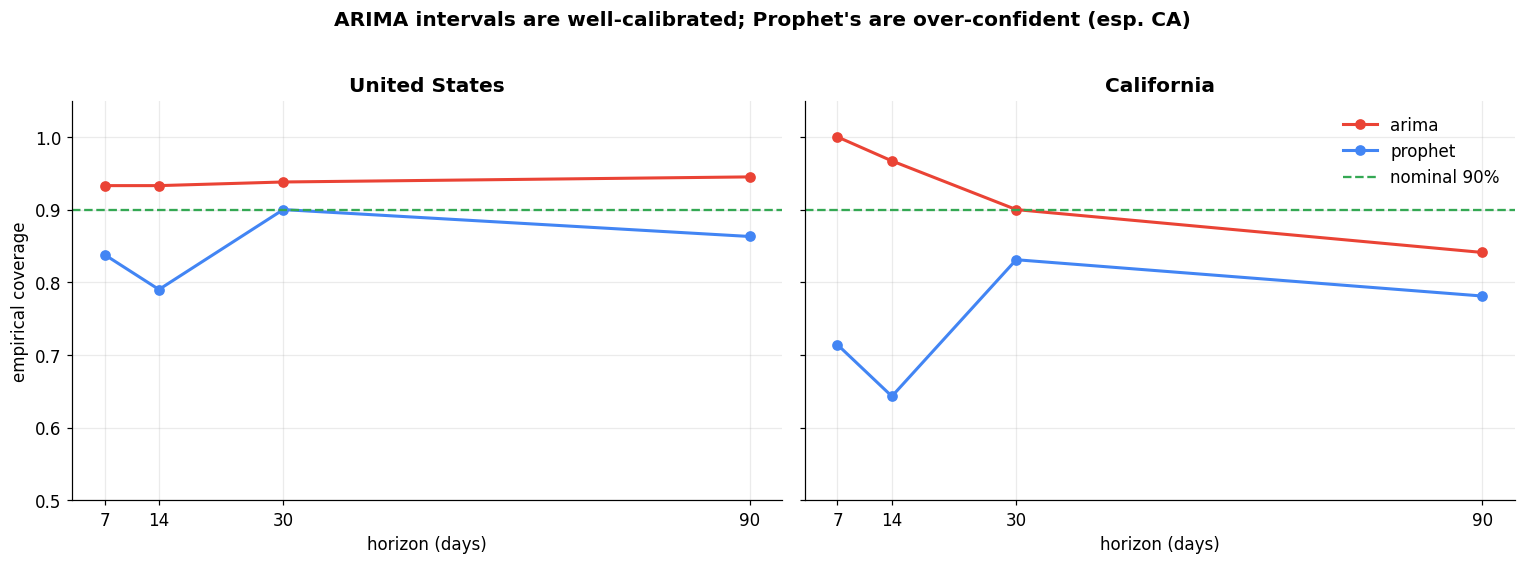

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, geo in zip(axes, ["United States", "California"]):
    d = cov[cov.series == geo]
    for model, color in [("arima", "#ea4335"), ("prophet", "#4285f4")]:
        dd = d[d.model == model].sort_values("horizon")
        ax.plot(dd.horizon, dd.empirical_coverage, "o-", color=color, lw=2, label=model)
    ax.axhline(0.90, color="#34a853", ls="--", lw=1.5, label="nominal 90%")
    ax.set_title(geo, fontweight="bold")
    ax.set_xlabel("horizon (days)"); ax.set_xticks([7, 14, 30, 90])
    ax.set_ylim(0.5, 1.05)
axes[0].set_ylabel("empirical coverage")
axes[1].legend(frameon=False)
fig.suptitle("ARIMA intervals are well-calibrated; Prophet's are over-confident (esp. CA)",
             fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(FIGS / "03_coverage.png", dpi=130, bbox_inches="tight"); plt.show()

**Reading it.** ARIMA+Fourier sits at or slightly above the 90% line almost everywhere —
honestly calibrated, even a touch conservative at short horizons (safe for staffing). Prophet is
consistently **below** nominal, and on California badly so: its "90%" interval captures only
~64–71% of actuals at 7–14 days. Prophet meaningfully understates its own uncertainty here.

## 2. Residual diagnostics (operational model: ARIMA+Fourier, h=7)

We inspect the pooled out-of-sample errors of the operational model — ARIMA at the 7-day
horizon — three ways: distribution (histogram), normality (QQ-plot), and autocorrelation (ACF).

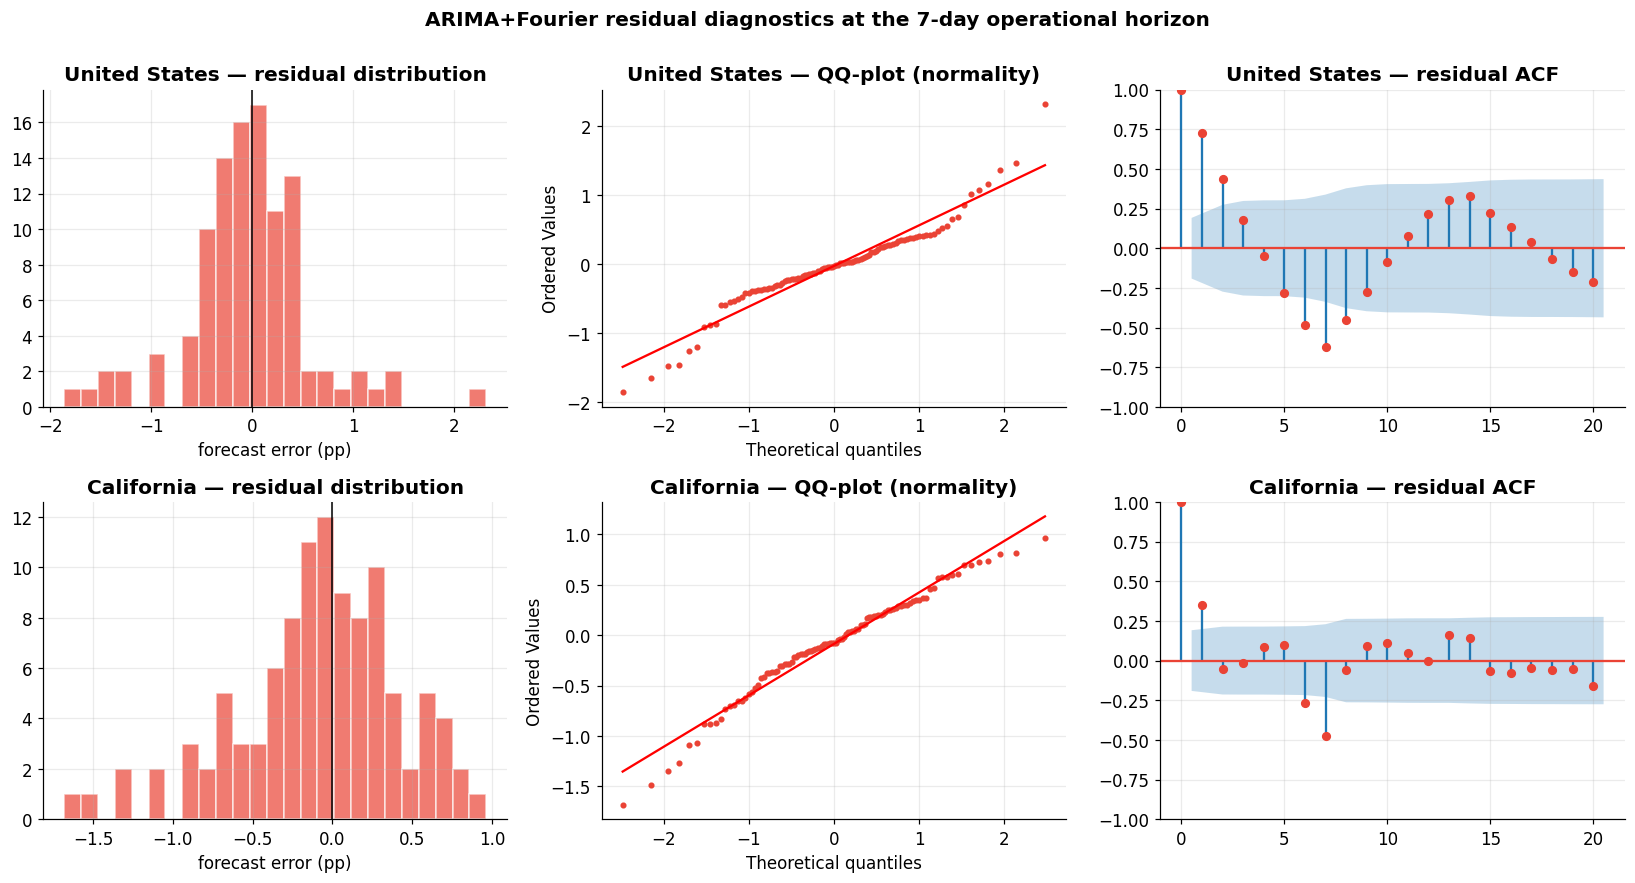

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, geo in enumerate(["United States", "California"]):
    e = ra[(ra.series == geo) & (ra.horizon == 7)].error.values
    # histogram
    ax = axes[row, 0]
    ax.hist(e, bins=25, color="#ea4335", alpha=0.7, edgecolor="white")
    ax.axvline(0, color="k", lw=1)
    ax.set_title(f"{geo} — residual distribution", fontweight="bold")
    ax.set_xlabel("forecast error (pp)")
    # QQ
    ax = axes[row, 1]
    stats.probplot(e, dist="norm", plot=ax)
    ax.set_title(f"{geo} — QQ-plot (normality)", fontweight="bold")
    ax.get_lines()[0].set_color("#ea4335"); ax.get_lines()[0].set_markersize(3)
    # ACF
    ax = axes[row, 2]
    plot_acf(e, ax=ax, lags=20, color="#ea4335")
    ax.set_title(f"{geo} — residual ACF", fontweight="bold")
fig.suptitle("ARIMA+Fourier residual diagnostics at the 7-day operational horizon",
             fontweight="bold", y=1.0)
fig.tight_layout(); fig.savefig(FIGS / "03_residuals_arima.png", dpi=130, bbox_inches="tight"); plt.show()

## 3. White-noise test (Ljung-Box) and bias

In [5]:
lbp = lb.pivot_table(index=["series", "horizon"], columns="model", values="lb_pvalue_lag10")
bias = lb.pivot_table(index=["series", "horizon"], columns="model", values="mean_error")
print("Ljung-Box p-value at lag 10 (H0: residuals are white noise):")
print(lbp.to_string())
print("\nMean error (bias, pp):")
print(bias.round(3).to_string())

Ljung-Box p-value at lag 10 (H0: residuals are white noise):
model                  arima  prophet
series        horizon                
California    7          0.0      0.0
              14         0.0      0.0
              30         0.0      0.0
              90         0.0      0.0
United States 7          0.0      0.0
              14         0.0      0.0
              30         0.0      0.0
              90         0.0      0.0

Mean error (bias, pp):
model                  arima  prophet
series        horizon                
California    7       -0.088    0.451
              14      -0.105    0.470
              30      -0.091   -0.282
              90      -0.106   -0.336
United States 7       -0.029    0.249
              14       0.069    0.341
              30       0.208   -0.415
              90       0.425   -0.601


**What the residuals say — stated honestly.**

- **Autocorrelation remains.** Ljung-Box p-values are ~0 for *both* models at *every* horizon:
  the residuals are **not** white noise. There is still day-to-day structure neither model fully
  captures. This is expected for a daily series and is reported rather than hidden — a model
  whose residuals were perfect white noise on real ED data would be more suspicious than
  reassuring.
- **Bias.** ARIMA is nearly unbiased at the operational horizon (US −0.03 pp, CA −0.09 pp).
  Prophet runs biased high at short horizons (US +0.25, CA +0.45) and biased low at long ones
  (US −0.60) — consistent with its flexible-then-stiff trend regimes overshooting and then
  lagging.
- **Spread.** ARIMA's residual std is smallest at short horizons (≈0.5–0.6 pp), confirming the
  MAPE story from a different angle.

The remaining autocorrelation is the honest ceiling of these models. Capturing it would require
explicitly modeling short-term dependence beyond what Fourier-ARIMA and Prophet do here — a
candidate for future work, not a defect to paper over.

## 4. The final scorecard

Pulling the whole project together: accuracy (MAPE), calibration (interval coverage), and the
operational recommendation, by horizon.

In [6]:
master = pd.read_csv(P / "master_comparison.csv")
cov_arima = cov[cov.model == "arima"][["series", "horizon", "empirical_coverage"]]
cov_arima = cov_arima.rename(columns={"empirical_coverage": "arima_cov90"})

score = master.merge(cov_arima, on=["series", "horizon"]).sort_values(["series", "horizon"])
show = score[["series", "horizon", "persistence_MAPE", "naive_MAPE",
              "prophet_MAPE", "arima_MAPE", "arima_cov90"]]
show.columns = ["Series", "h", "Persist", "Seas-naive", "Prophet", "ARIMA", "ARIMA cov90"]
show

,Series,h,Persist,Seas-naive,Prophet,ARIMA,ARIMA cov90
0,California,7,4.64,9.36,9.12,3.51,1.000
1,California,14,5.70,9.83,11.04,5.14,0.967
2,California,30,9.58,10.25,11.77,8.53,0.900
3,California,90,18.87,10.44,13.70,15.08,0.841
4,United States,7,5.03,10.76,4.53,3.29,0.933
5,United States,14,6.95,11.04,5.60,5.12,0.933
6,United States,30,10.76,11.50,8.20,7.63,0.938
7,United States,90,21.83,12.14,8.82,12.07,0.945


## 5. Final verdict

**Accuracy + calibration together point the same way.** ARIMA+Fourier is not only the most
accurate model at the operational 0–14 day horizon (MAPE ~3–5%) — it is also the best-calibrated
(90% intervals that actually cover ~90%) and the least biased. Prophet, even with the honest
two-regime trend rule, is beaten on accuracy at short horizons and additionally understates its
uncertainty, especially on California.

**The horizon-aware recommendation, now backed by diagnostics:**

| Horizon | Use | Why |
|---|---|---|
| **0–14 days** | **ARIMA+Fourier** | best MAPE, well-calibrated intervals, ~unbiased |
| **~30 days** | ARIMA or Prophet | parity; pick by operational preference |
| **90 days** | **Seasonal-naive** (or stiff Prophet on US) | complex models degrade to/below baseline; intervals less reliable |

**What makes this project defensible** is the chain of self-correction it documents: naive
baselines first; identical CV windows for every model; a directly-measured hyperparameter
optimism gap (02c); and now residual + coverage diagnostics that test the chosen model rather
than just celebrating its point error. The result is a forecast you can put in front of a
staffing planner *with* an honest statement of when to trust it and when to fall back to a
one-line baseline.